<a href="https://colab.research.google.com/github/Auta01/Hugging-face/blob/main/Converting_image_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
import diffusers
import transformers
import cv2

In [6]:
from diffusers import StableVideoDiffusionPipeline

In [ ]:
pipe = StableVideoDiffusionPipeline.from_pretrained('stabilityai/stable-video-diffusion-img2vid-xt',
                                                    torch_dtype=torch.float16,
                                                    variant='fp16')

In [ ]:
pipe

In [9]:
path ='/content/my photo.PNG'

In [10]:
path

'/content/my photo.PNG'

In [11]:
from diffusers.utils import load_image, export_to_video


In [24]:
image = load_image(path)

In [ ]:
image

In [13]:
pipe.enable_model_cpu_offload()

In [14]:
generator = torch.manual_seed(42)

In [15]:
generator

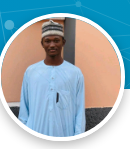

In [25]:
image

In [ ]:
frames =pipe(image,decode_chunk_size=8, generator=generator).frames[0]

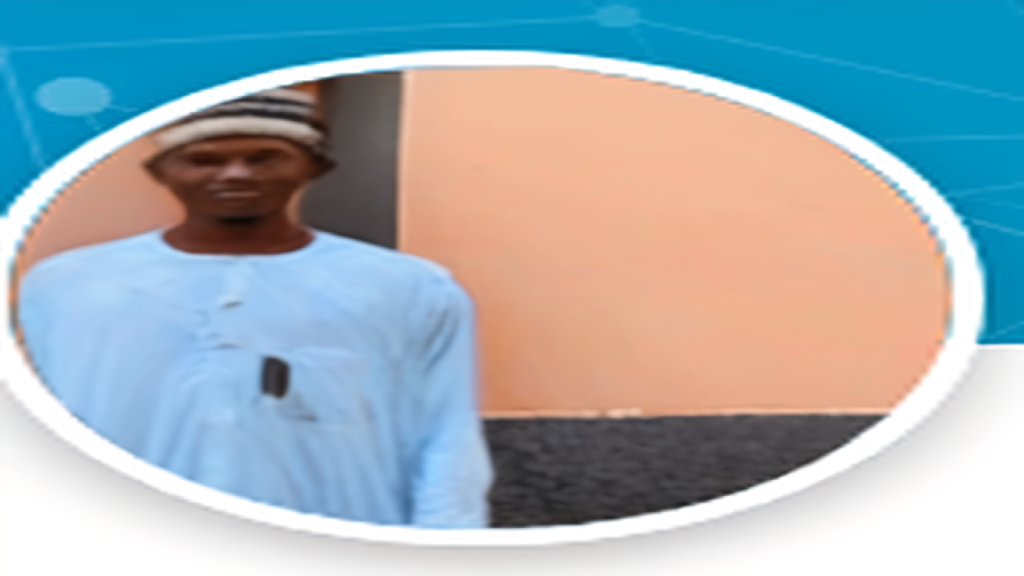

In [27]:
frames[7]

In [28]:
len(frames)

25

In [29]:
export_to_video(frames,'/content/my_video.mp4',fps=7 )

'/content/my_video.mp4'

In [21]:
##Generating video using another diffusion model(using and prompt)

In [30]:
import torch
torch.cuda.empty_cache()

In [31]:
from diffusers import I2VGenXLPipeline

In [33]:
repo_id ='ali-vilab/i2vgen-xl'

In [ ]:
pipeline = I2VGenXLPipeline.from_pretrained(repo_id,torch_dtype=torch.float16,
                                            variant ='fp16')

In [35]:
pipeline.enable_model_cpu_offload()

In [36]:
outreachy = load_image('/content/outreachy.PNG')

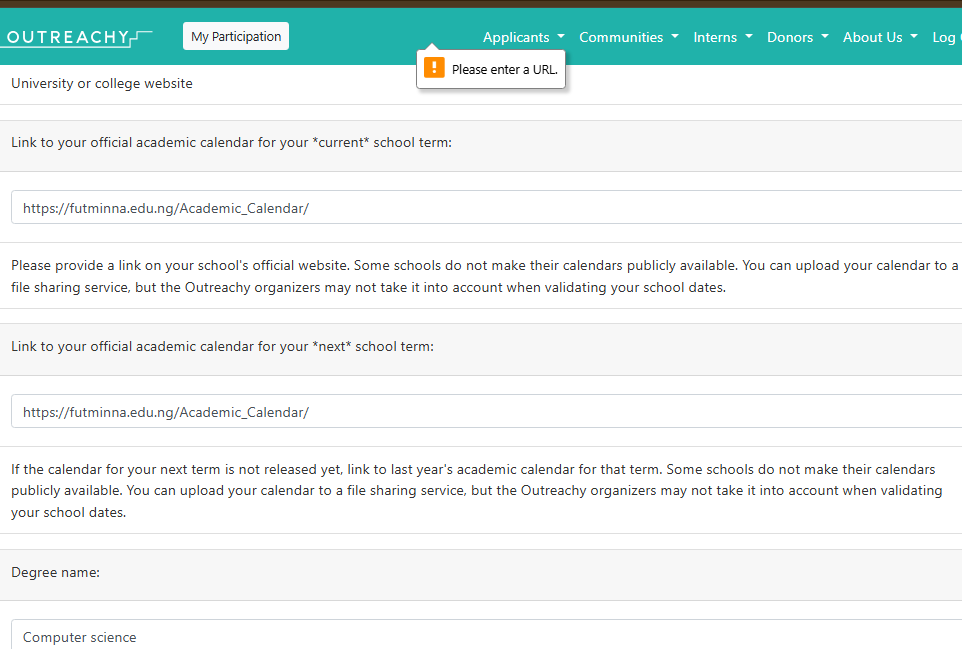

In [37]:
outreachy

In [38]:
prompt = 'the outreachy waves heavily'

In [40]:
generator = torch.manual_seed(42)

In [42]:
frames = pipeline(prompt=prompt,
                  image=outreachy,
                  num_frames=16,
                  generator=generator,
                  ).frames[0]

  0%|          | 0/50 [00:00<?, ?it/s]

In [43]:
frames

[<PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>]

In [45]:
export_to_video(frames, 'outreachy.mp4',fps=8)

'outreachy.mp4'